# 10 - ESA OPSSAT-AD Feature Extraction Pipeline

Amaç ham telemetri segmentlerinden (`segments.csv`) ESA OPSSAT-AD makalesinde tanımlanan 18 handcrafted özelliği otomatik olarak çıkarmak ve `dataset.csv` ile aynı şemayı yeniden üretmek.

```
segments.csv  -->   extract_esa_features()  -->  dataset.csv
303,493 satır       segment bazlı özet           2,123 segment x 23 sütun
ham sinyal                                       18 özellik ve 5 meta
```


---
## Bölüm 1: Hazırlık ve Veri Yükleme

In [2]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.signal import find_peaks
from scipy import stats as sp_stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '..')
from src.feature_engineer import extract_esa_features

In [3]:
df_segments = pd.read_csv('../data/raw/segments.csv')

df_dataset = pd.read_csv('../data/raw/dataset.csv')

print(f'segments.csv : {df_segments.shape}  (ham sinyal)')
print(f'dataset.csv  : {df_dataset.shape}  (ESA referans özellikleri)')
print(f'\nsegments.csv sütunları: {list(df_segments.columns)}')
print(f'dataset.csv sütunları : {list(df_dataset.columns)}')


segments.csv : (303493, 8)  (ham sinyal)
dataset.csv  : (2123, 23)  (ESA referans özellikleri)

segments.csv sütunları: ['channel', 'timestamp', 'value', 'label', 'sampling', 'anomaly', 'segment', 'train']
dataset.csv sütunları : ['segment', 'anomaly', 'train', 'channel', 'sampling', 'duration', 'len', 'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var', 'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len']


---
## Bölüm 2: 18 Özelliğin Anatomisi
ESA OPSSAT-AD özellikleri 3 mantıksal gruba ayrılır. Her grup sinyalin farklı bir yönünü yakalar:

### Grup 1, Ham Segmentten (12 özellik)
| Özellik | Açıklama |
|---------|----------|
| `mean`, `var`, `std` | Temel istatistikler |
| `kurtosis`, `skew` | Dağılım şekli |
| `n_peaks` | Tepe sayısı (%10 prominence ile) |
| `len`, `duration` | Veri noktası sayısı, süre |
| `gaps_squared` | Zaman farklarının kareler toplamı |
| `len_weighted` | `len x sampling` |
| `var_div_duration`, `var_div_len` | Normalize varyans oranları |

### Grup 2, Yumuşatılmış Segmentten (2 özellik)
| Özellik | Açıklama |
|---------|----------|
| `smooth10_n_peaks` | 10-noktalı hareketli ortalama sonrası tepe sayısı |
| `smooth20_n_peaks` | 20-noktalı hareketli ortalama sonrası tepe sayısı |

### Grup 3, Türevlerden (4 özellik)
| Özellik | Açıklama |
|---------|----------|
| `diff_peaks`, `diff2_peaks` | 1. ve 2. türevdeki tepe sayısı |
| `diff_var`, `diff2_var` | 1. ve 2. türevin varyansı |

Ayrıca 5 meta sütun taşınır: `segment`, `anomaly`, `train`, `channel`, `sampling`.


In [4]:
FEATURE_GROUPS = {
    'Grup 1 - Ham (12)': ['mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks',
                          'len', 'duration', 'gaps_squared', 'len_weighted',
                          'var_div_duration', 'var_div_len'],
    'Grup 2 - Yumuşak (2)': ['smooth10_n_peaks', 'smooth20_n_peaks'],
    'Grup 3 - Türev (4)': ['diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var'],
}
META_COLS = ['segment', 'anomaly', 'train', 'channel', 'sampling']

total = sum(len(v) for v in FEATURE_GROUPS.values())
print(f'Toplam özellik: {total}  (+ {len(META_COLS)} meta sütun = {total + len(META_COLS)} sütun)\n')
for grp, feats in FEATURE_GROUPS.items():
    print(f'{grp}: {feats}')

all_feats = [f for feats in FEATURE_GROUPS.values() for f in feats]
missing = [f for f in all_feats if f not in df_dataset.columns]
print(f'\ndataset.csv içinde eksik özellik: {missing if missing else "yok"}')


Toplam özellik: 18  (+ 5 meta sütun = 23 sütun)

Grup 1 - Ham (12): ['mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'len', 'duration', 'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len']
Grup 2 - Yumuşak (2): ['smooth10_n_peaks', 'smooth20_n_peaks']
Grup 3 - Türev (4): ['diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var']

dataset.csv içinde eksik özellik: yok


---
## Bölüm 3: Tek Segment Üzerinde Adım Adım Çıkarım
Pipeline'ın iç mantığını anlamak için tek bir segmenti elle işliyoruz. Her grubu sırayla hesaplayıp görselleştiriyoruz. Sonunda elle hesabımızı `extract_esa_features` çıktısıyla karşılaştırarak doğruluğu teyit ediyoruz.


In [5]:
seg_id = df_segments[df_segments['anomaly'] == 1]['segment'].iloc[0]
seg = df_segments[df_segments['segment'] == seg_id].copy()
val = seg['value'].values
n = len(val)

print(f'Segment {seg_id}:  kanal={seg["channel"].iloc[0]}, '
      f'uzunluk={n}, anomali={seg["anomaly"].iloc[0]}')

prominence_ratio = 0.10
p2p = np.ptp(val)
prom = prominence_ratio * p2p if p2p > 0 else None
peaks, _ = find_peaks(val, prominence=prom)

print(f'\n[Grup 1] mean={np.mean(val):.4e}  var={np.var(val):.4e}  std={np.std(val):.4e}')
print(f'[Grup 1] kurtosis={sp_stats.kurtosis(val):.4f}  skew={sp_stats.skew(val):.4f}')
print(f'[Grup 1] n_peaks={len(peaks)}  (prominence = %{prominence_ratio*100:.0f} × {p2p:.2e})')


Segment 1:  kanal=CADC0872, uzunluk=280, anomali=1

[Grup 1] mean=8.5331e-07  var=3.4943e-10  std=1.8693e-05
[Grup 1] kurtosis=0.6311  skew=0.5521
[Grup 1] n_peaks=4  (prominence = %10 × 9.17e-05)


In [6]:
s10 = np.convolve(val, np.ones(10) / 10, mode='same')
s20 = np.convolve(val, np.ones(20) / 20, mode='same')
prom10 = prominence_ratio * np.ptp(s10) if np.ptp(s10) > 0 else None
prom20 = prominence_ratio * np.ptp(s20) if np.ptp(s20) > 0 else None
pk10, _ = find_peaks(s10, prominence=prom10)
pk20, _ = find_peaks(s20, prominence=prom20)

diff1 = np.diff(val)
diff2 = np.diff(diff1)
prom_d1 = prominence_ratio * np.ptp(diff1) if np.ptp(diff1) > 0 else None
dpk1, _ = find_peaks(diff1, prominence=prom_d1)
diff_var = np.var(diff1)
diff2_var = np.var(diff2)

print(f'[Grup 2] smooth10_n_peaks={len(pk10)}  smooth20_n_peaks={len(pk20)}')
print(f'[Grup 3] diff_peaks={len(dpk1)}  diff_var={diff_var:.4e}  diff2_var={diff2_var:.4e}')


[Grup 2] smooth10_n_peaks=3  smooth20_n_peaks=2
[Grup 3] diff_peaks=4  diff_var=1.2712e-10  diff2_var=2.9607e-10


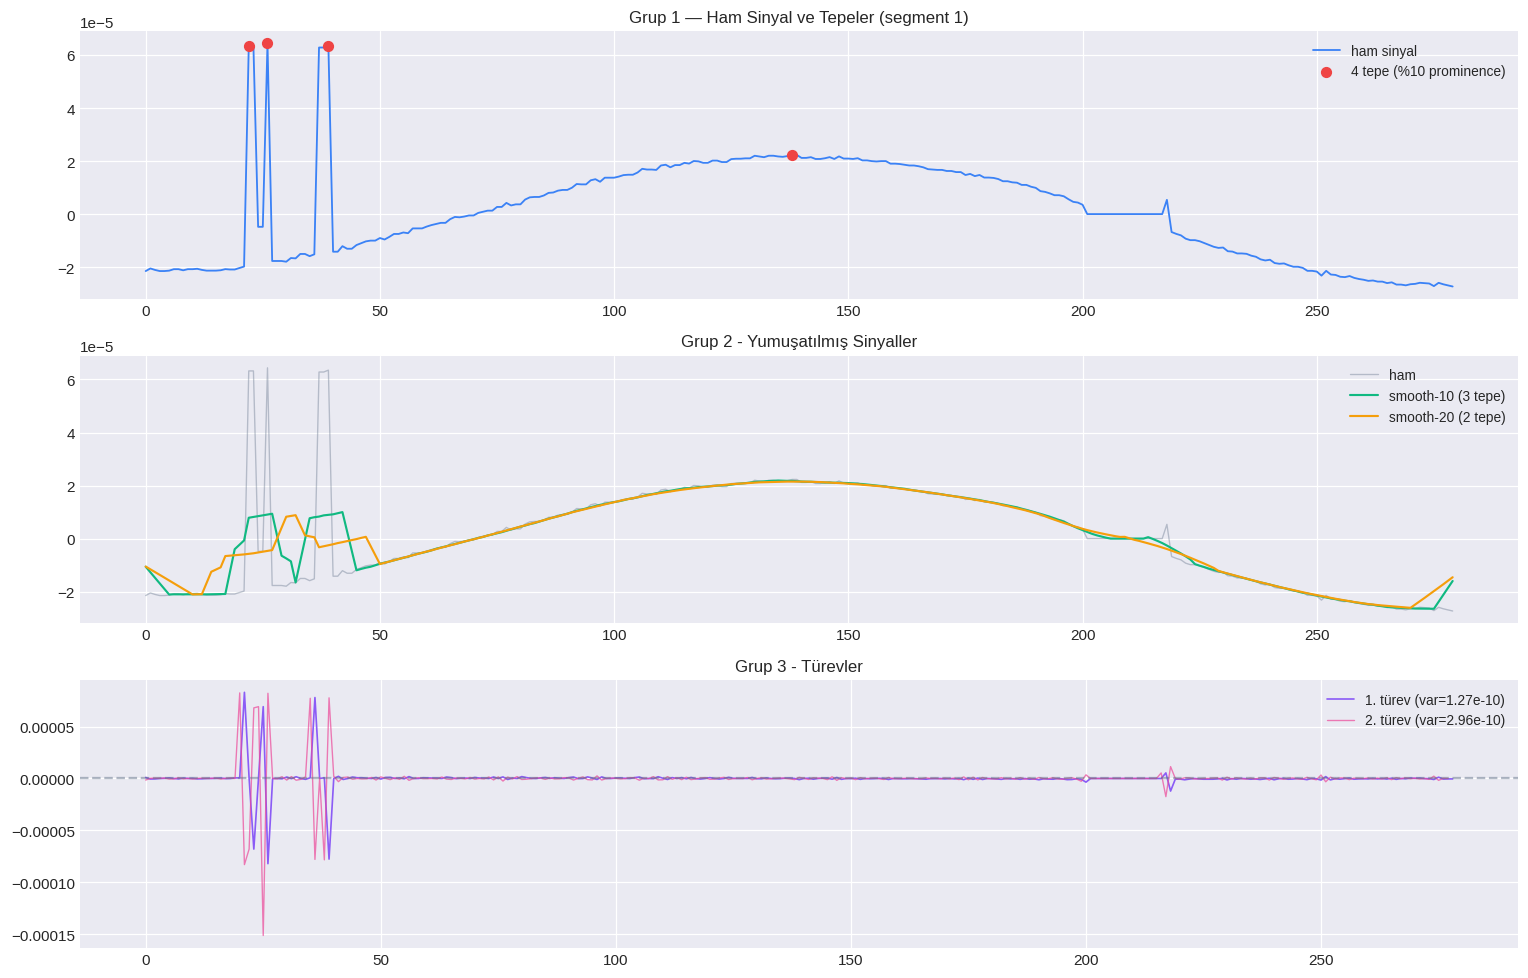

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

axes[0].plot(val, color='#3B82F6', linewidth=1.2, label='ham sinyal')
axes[0].scatter(peaks, val[peaks], color='#EF4444', s=40, zorder=5,
                label=f'{len(peaks)} tepe (%10 prominence)')
axes[0].set_title(f'Grup 1 — Ham Sinyal ve Tepeler (segment {seg_id})', fontsize=11)
axes[0].legend(fontsize=9)

axes[1].plot(val, color='#64748B', alpha=0.4, linewidth=0.9, label='ham')
axes[1].plot(s10, color='#10B981', linewidth=1.4, label=f'smooth-10 ({len(pk10)} tepe)')
axes[1].plot(s20, color='#F59E0B', linewidth=1.4, label=f'smooth-20 ({len(pk20)} tepe)')
axes[1].set_title('Grup 2 - Yumuşatılmış Sinyaller', fontsize=11)
axes[1].legend(fontsize=9)

axes[2].plot(diff1, color='#8B5CF6', linewidth=1.1, label=f'1. türev (var={diff_var:.2e})')
axes[2].plot(diff2, color='#EC4899', linewidth=0.9, alpha=0.7,
             label=f'2. türev (var={diff2_var:.2e})')
axes[2].axhline(0, color='#64748B', linestyle='--', alpha=0.5)
axes[2].set_title('Grup 3 - Türevler', fontsize=11)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


In [8]:
single_out = extract_esa_features(seg)
check_cols = ['mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks',
              'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks',
              'diff_var', 'diff2_var']
single_out[check_cols].T.rename(columns={single_out.index[0]: 'pipeline'})


  [1/1] segment isleniyor...
Tamamlandi: 1 segment, 18 ozellik cikarildi.


,pipeline
mean,8.533143e-07
var,3.494283e-10
std,1.869300e-05
kurtosis,6.311174e-01
skew,5.520523e-01
n_peaks,4.000000e+00
smooth10_n_peaks,3.000000e+00
smooth20_n_peaks,2.000000e+00
diff_peaks,4.000000e+00
diff_var,1.271176e-10


---
## Bölüm 4: Pipeline'ı Tüm Veriye Uygulama
Şimdi `extract_esa_features` fonksiyonunu tüm `segments.csv` üzerinde çalıştırıp, ESA'nın `dataset.csv` formatını sıfırdan yeniden üretiyoruz. Bu, ~303K satırlık ham veriyi 2123 segmentlik özet tabloya indirger.


In [9]:
df_reconstructed = extract_esa_features(df_segments)

print(f'\nYeniden üretilen tablo: {df_reconstructed.shape}')
print(f'ESA orijinali        : {df_dataset.shape}')
df_reconstructed.head()


  [200/2123] segment isleniyor...
  [400/2123] segment isleniyor...
  [600/2123] segment isleniyor...
  [800/2123] segment isleniyor...
  [1000/2123] segment isleniyor...
  [1200/2123] segment isleniyor...
  [1400/2123] segment isleniyor...
  [1600/2123] segment isleniyor...
  [1800/2123] segment isleniyor...
  [2000/2123] segment isleniyor...
  [2123/2123] segment isleniyor...
Tamamlandi: 2123 segment, 18 ozellik cikarildi.

Yeniden üretilen tablo: (2123, 23)
ESA orijinali        : (2123, 23)


,segment,anomaly,train,channel,sampling,duration,len,mean,var,std,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,1,1,1,CADC0872,1,279,280,8.533143e-07,3.494283e-10,0.000019,...,3,2,4,6,1.271176e-10,2.960666e-10,309,280,1.252431e-12,1.247958e-12
1,2,1,1,CADC0872,1,476,477,-3.639396e-06,6.476485e-10,0.000025,...,1,1,5,8,1.489383e-12,3.004752e-12,644,477,1.360606e-12,1.357754e-12
2,3,1,1,CADC0872,1,594,595,1.170788e-05,5.592877e-10,0.000024,...,2,2,2,3,4.112280e-12,1.029918e-11,772,595,9.415618e-13,9.399794e-13
3,4,1,1,CADC0872,1,271,272,8.486808e-07,5.466024e-10,0.000023,...,2,2,3,6,2.475760e-11,6.240985e-11,339,272,2.016983e-12,2.009568e-12
4,5,0,0,CADC0872,1,255,257,1.058485e-05,5.279023e-10,0.000023,...,1,1,78,87,5.547101e-13,7.035422e-13,357,257,2.070205e-12,2.054094e-12


---
## Bölüm 5: ESA Orijinali ile Doğrulama
Otomatik pipeline'ımızın ürettiği özelliklerin, ESA'nın elle hesaplanmış `dataset.csv` değerleriyle ne kadar örtüştüğünü ölçeceğiz. İki tabloyu `segment` üzerinden eşleştirip her özellik için korelasyon ve ortalama bağıl hatayı hesaplıyoruz.


In [10]:
merge_feats = ['mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks',
               'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks',
               'diff_var', 'diff2_var', 'len', 'duration']
merge_feats = [f for f in merge_feats if f in df_dataset.columns and f in df_reconstructed.columns]

merged = df_dataset[['segment'] + merge_feats].merge(
    df_reconstructed[['segment'] + merge_feats],
    on='segment', suffixes=('_esa', '_bizim'))

val_rows = []
for f in merge_feats:
    esa = merged[f'{f}_esa']
    bizim = merged[f'{f}_bizim']
    corr = esa.corr(bizim)
    denom = esa.abs().replace(0, np.nan)
    mare = ((esa - bizim).abs() / denom).replace([np.inf, -np.inf], np.nan).mean()
    val_rows.append({'Özellik': f, 'Korelasyon': corr, 'Ort. Bağıl Hata': mare})

df_valid = pd.DataFrame(val_rows)
df_valid.style.format({'Korelasyon': '{:.4f}', 'Ort. Bağıl Hata': '{:.3%}'}) \
    .background_gradient(subset=['Korelasyon'], cmap='RdYlGn', vmin=0.8, vmax=1.0)


,Özellik,Korelasyon,Ort. Bağıl Hata
0,mean,1.0000,0.000%
1,var,1.0000,0.000%
2,std,1.0000,0.000%
3,kurtosis,1.0000,0.000%
4,skew,1.0000,0.000%
5,n_peaks,1.0000,0.000%
6,smooth10_n_peaks,1.0000,0.000%
7,smooth20_n_peaks,0.9819,0.474%
8,diff_peaks,1.0000,0.000%
9,diff2_peaks,1.0000,0.000%


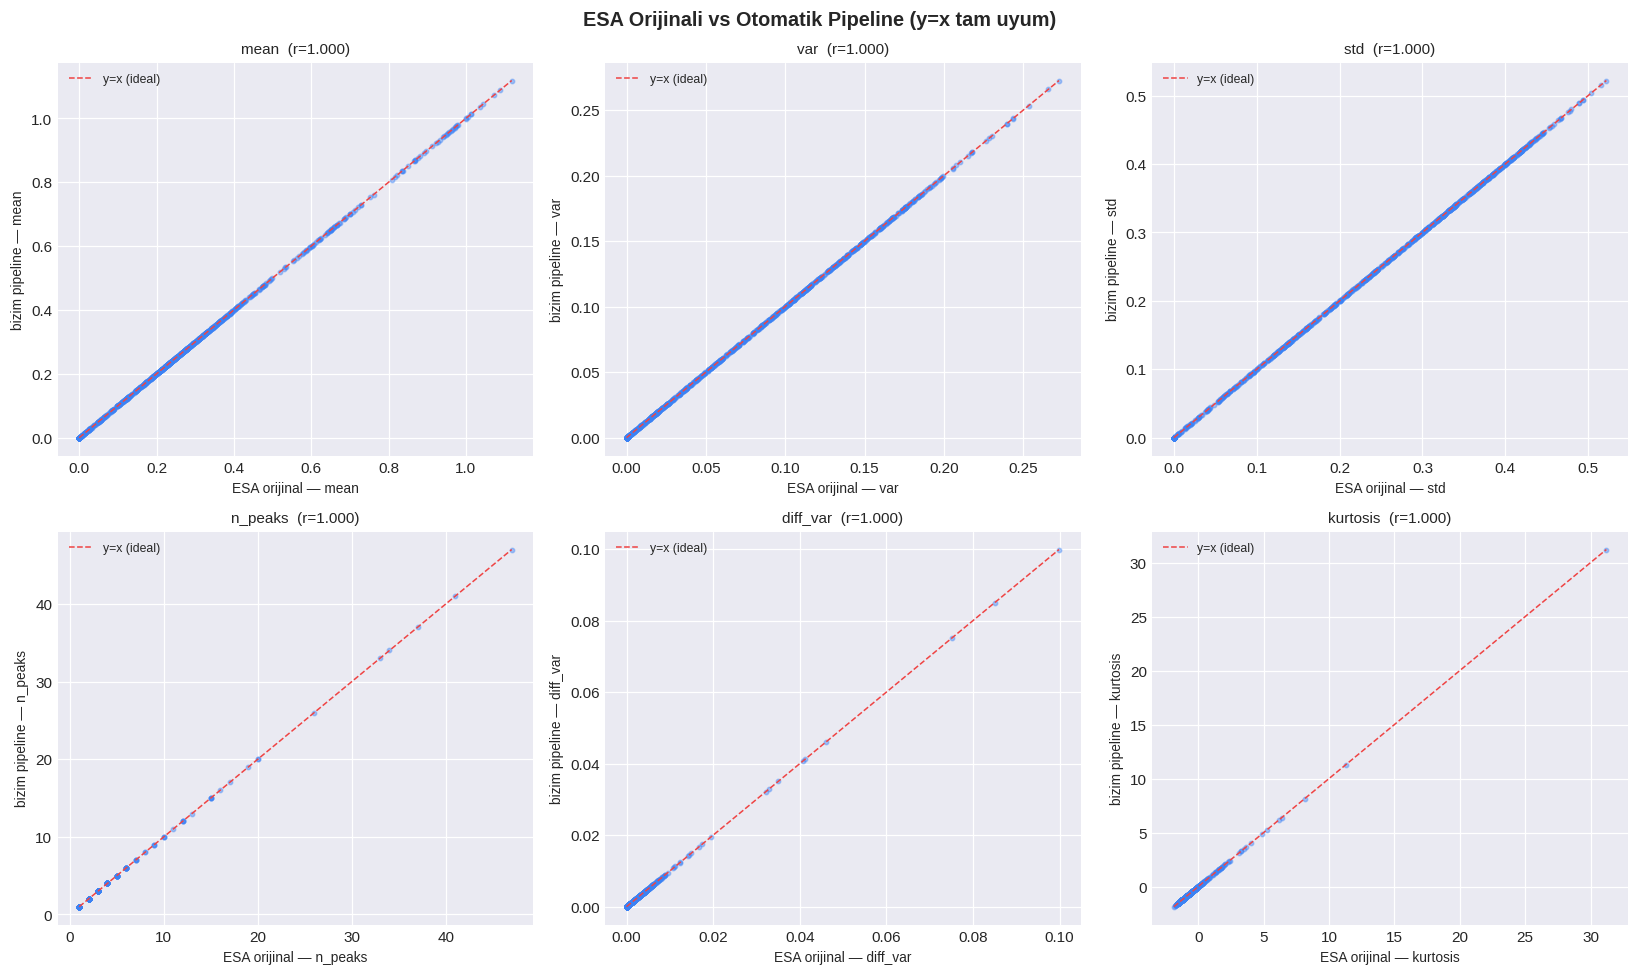

In [11]:
plot_feats = [f for f in ['mean', 'var', 'std', 'n_peaks', 'diff_var', 'kurtosis']
              if f in merge_feats][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ax, f in zip(axes, plot_feats):
    esa = merged[f'{f}_esa']
    bizim = merged[f'{f}_bizim']
    ax.scatter(esa, bizim, s=8, alpha=0.4, color='#3B82F6')
    lims = [min(esa.min(), bizim.min()), max(esa.max(), bizim.max())]
    ax.plot(lims, lims, color='#EF4444', linestyle='--', linewidth=1, label='y=x (ideal)')
    ax.set_xlabel(f'ESA orijinal — {f}', fontsize=9)
    ax.set_ylabel(f'bizim pipeline — {f}', fontsize=9)
    ax.set_title(f'{f}  (r={esa.corr(bizim):.3f})', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('ESA Orijinali vs Otomatik Pipeline (y=x tam uyum)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Bölüm 6: Özelliklerin Anomali Ayırt Ediciliği
Çıkarılan özelliklerin gerçekten işe yarayıp yaramadığını kontrol ediyoruz. Anomali ve normal segmentler arasında en çok ayrışan özellikleri, varyans oranı ile sıralıyoruz. Yüksek oran, o özelliğin anomalilerde daha değişken olduğunu gösterir.


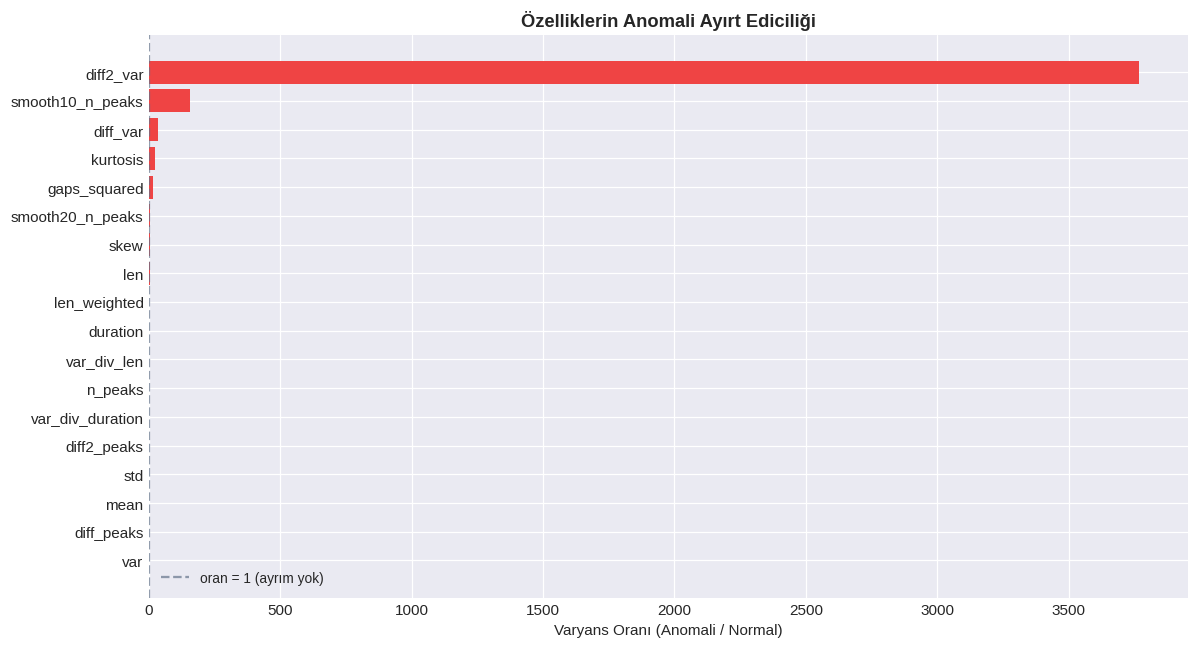

En ayırt edici 5 özellik:
diff2_var           3766.22
smooth10_n_peaks     155.33
diff_var              33.39
kurtosis              23.54
gaps_squared          13.72


In [12]:
feat_cols = [f for grp in FEATURE_GROUPS.values() for f in grp if f in df_reconstructed.columns]
normal = df_reconstructed[df_reconstructed['anomaly'] == 0]
anomaly = df_reconstructed[df_reconstructed['anomaly'] == 1]

var_ratios = {}
for c in feat_cols:
    n_var = normal[c].var()
    a_var = anomaly[c].var()
    if n_var > 0:
        var_ratios[c] = a_var / n_var

sr = pd.Series(var_ratios).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#EF4444' if v > 2 else '#F59E0B' if v > 1 else '#10B981' for v in sr.values]
ax.barh(sr.index[::-1], sr.values[::-1], color=colors[::-1])
ax.axvline(1.0, color='#64748B', linestyle='--', alpha=0.7, label='oran = 1 (ayrım yok)')
ax.set_xlabel('Varyans Oranı (Anomali / Normal)')
ax.set_title('Özelliklerin Anomali Ayırt Ediciliği', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('En ayırt edici 5 özellik:')
print(sr.head().round(2).to_string())


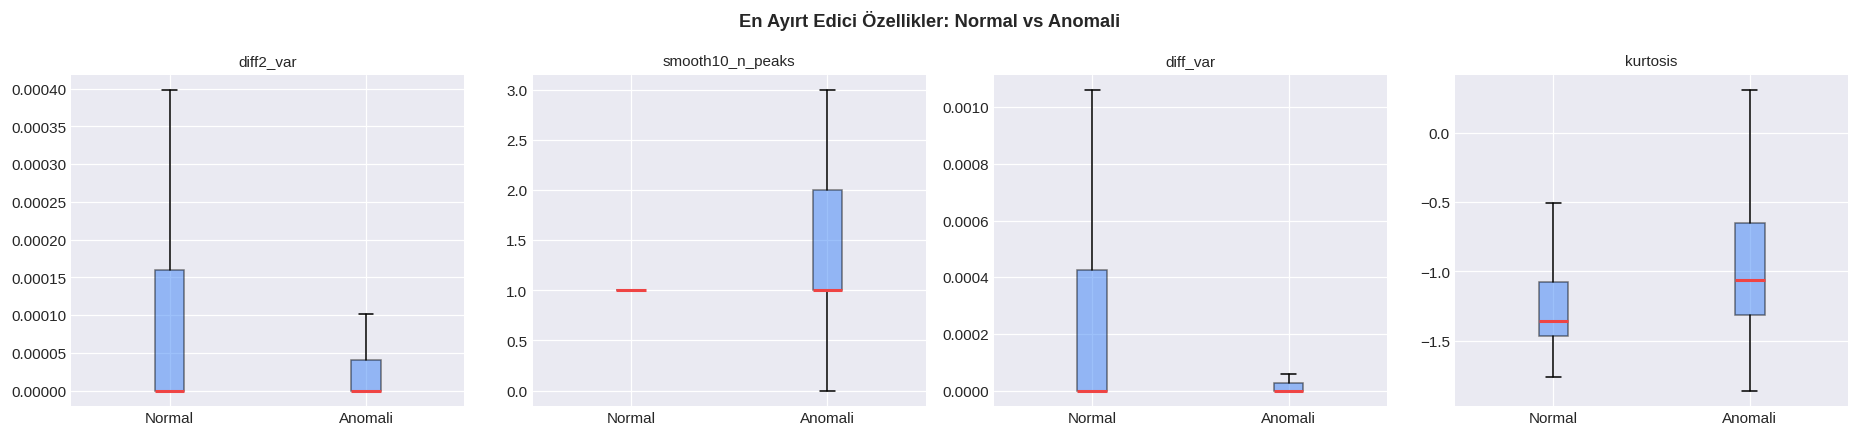

In [13]:
top_feats = sr.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, f in zip(axes, top_feats):
    ax.boxplot([normal[f].dropna(), anomaly[f].dropna()],
               labels=['Normal', 'Anomali'], showfliers=False,
               patch_artist=True,
               boxprops=dict(facecolor='#3B82F6', alpha=0.5),
               medianprops=dict(color='#EF4444', linewidth=2))
    ax.set_title(f, fontsize=10)
plt.suptitle('En Ayırt Edici Özellikler: Normal vs Anomali', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Bölüm 7: Kaydetme
Yeniden üretilen özellik matrisini kaydediyoruz. Gerçek `data/raw/dataset.csv` ezilmez; çıktı ayrı bir dosyaya yazılır; böylece ESA orijinali ile otomatik üretim yan yana saklanır.


In [14]:
os.makedirs('../data/features', exist_ok=True)
out_path = '../data/features/dataset_reconstructed.csv'
df_reconstructed.to_csv(out_path, index=False)
print(f'Yeniden üretilen özellik matrisi kaydedildi: {out_path}')
print(f'Boyut: {df_reconstructed.shape[0]} segment x {df_reconstructed.shape[1]} sütun')


Yeniden üretilen özellik matrisi kaydedildi: ../data/features/dataset_reconstructed.csv
Boyut: 2123 segment x 23 sütun
